In [1]:
import plotly.offline as pyo
from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
init_notebook_mode(connected=True)

In [2]:
import cufflinks as cf
cf.go_offline()

In [3]:
import pandas as pd
df1 = pd.read_csv('kgh_d.csv', parse_dates=True)
df1.head()

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen
0,2015-01-02,102.45,102.83,101.97,102.40,309987
1,2015-01-05,102.16,102.88,99.91,100.09,479228
2,2015-01-07,100.53,105.45,99.67,104.89,966372
3,2015-01-08,105.35,107.15,105.35,107.11,711805
4,2015-01-09,107.15,107.15,103.87,104.33,563221


In [4]:
import pandas as pd
df2 = pd.read_csv('ca_c_f_d.csv', parse_dates=True)
df2.head()

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie
0,2015-01-02,6309.0,6309.0,6309.0,6309.0
1,2015-01-05,6216.0,6216.0,6216.0,6216.0
2,2015-01-06,6191.0,6191.0,6191.0,6191.0
3,2015-01-07,6170.0,6170.0,6170.0,6170.0
4,2015-01-08,6230.5,6230.5,6230.5,6230.5


In [5]:
import plotly.offline as pyo
import plotly.graph_objects as go

In [6]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [7]:
fig = make_subplots(rows=2, cols=1, subplot_titles=["KGHM", "Miedź"], shared_xaxes=True)

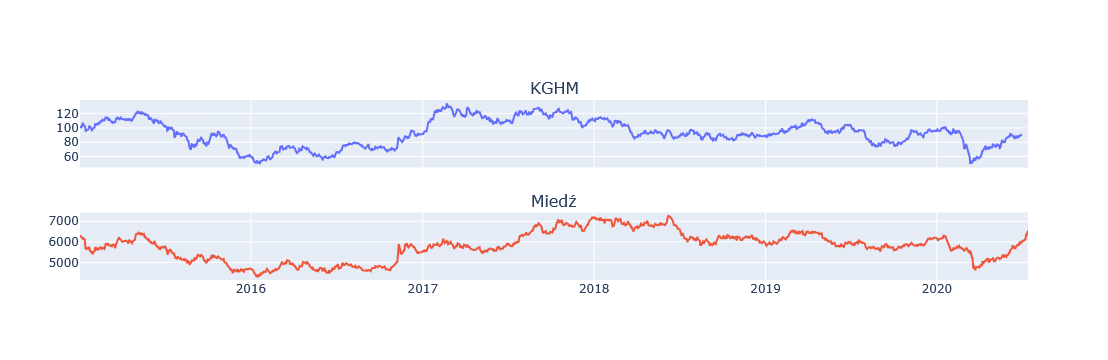

In [8]:
fig.add_trace(go.Scatter(x=df1['Data'],y=df1['Zamkniecie'], showlegend=False), row=1, col=1)

fig.add_trace(go.Scatter(x=df2['Data'],y=df2['Zamkniecie'], showlegend=False), row=2, col=1)

In [9]:
df1 = df1.rename(columns={'Zamkniecie': 'KGHM'})
new_df1 = df1[['Data','KGHM']]
new_df1.head()

,Data,KGHM
0,2015-01-02,102.40
1,2015-01-05,100.09
2,2015-01-07,104.89
3,2015-01-08,107.11
4,2015-01-09,104.33


In [10]:
df2 = df2.rename(columns={'Zamkniecie': 'Miedź'})
new_df2 = df2[['Data','Miedź']]
new_df2.head()

,Data,Miedź
0,2015-01-02,6309.0
1,2015-01-05,6216.0
2,2015-01-06,6191.0
3,2015-01-07,6170.0
4,2015-01-08,6230.5


In [11]:
new_df = pd.merge(new_df1, new_df2, how='inner', on='Data')
new_df.head()

,Data,KGHM,Miedź
0,2015-01-02,102.40,6309.0
1,2015-01-05,100.09,6216.0
2,2015-01-07,104.89,6170.0
3,2015-01-08,107.11,6230.5
4,2015-01-09,104.33,6151.0


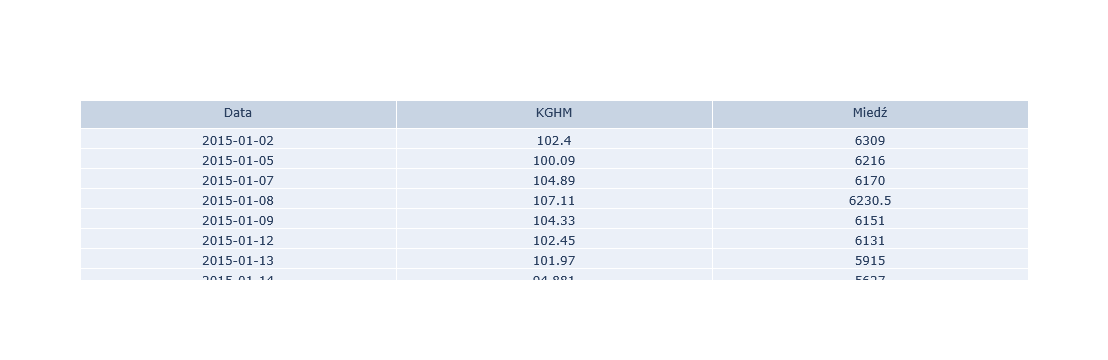

In [12]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(
    header=dict(values=list(new_df.columns)),
    cells=dict(values=[new_df[col] for col in new_df.columns])
)])

fig.show()